In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,roc_auc_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing the dataset
data=pd.read_csv(r"C:\Users\vivek\Telco Customer Churn Analysis\Telco_Customer_Churn_Dataset  (1).csv")
pd.reset_option('display.max_columns',None)

In [4]:
# Display the first five rows of the dataset
print("Head of the dataset:")
data.head().style.set_properties(**{'background-color':'#f4c095','color':'black','border':'2.5px solid black'})

Head of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850000,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950000,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850000,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700000,151.65,Yes


In [5]:
# Display the last five rows of the dataset
print("Tail of the dataset:")
data.tail().style.set_properties(**{'background-color':'#f4c095','color':'black','border':'2.5px solid black'})

Tail of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.800000,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.200000,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.600000,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.400000,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.650000,6844.5,No


In [6]:
# Number of records in the dataset
print('Number of records in the dataset:', len(data))

# Dimensions of the dataset (rows, columns)
print('Dimensions of the dataset:', data.shape)

Number of records in the dataset: 7043
Dimensions of the dataset: (7043, 21)


In [7]:
# The replace() method with regex=True replaces all blank spaces (\s*) with NaN values in the entire DataFrame
data.replace(r'^\s*$', np.nan, regex=True, inplace=True)

In [8]:
# Display information about the dataset, including data types and non-null counts
print("Information about the dataset:")
print(data.info())

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBi

In [9]:
# Dropping the missing values
data.dropna(inplace=True)

In [10]:
# Displaying summary statistics of the dataset
print("Summary statistics:")
data.describe().T.style.set_properties(**{'background-color':'#f4c095','color':'black','border':'2.5px solid black'})

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.000000,0.162400,0.368844,0.000000,0.000000,0.000000,0.000000,1.000000
tenure,7032.000000,32.421786,24.545260,1.000000,9.000000,29.000000,55.000000,72.000000
MonthlyCharges,7032.000000,64.798208,30.085974,18.250000,35.587500,70.350000,89.862500,118.750000


In [11]:
# Dropping Customer ID column
data.drop('customerID',axis=1,inplace=True)

In [12]:
# Value Counts for each column
value_counts_gender = data['gender'].value_counts()
value_counts_senior_citizen = data['SeniorCitizen'].value_counts()
value_counts_partner = data['Partner'].value_counts()
value_counts_dependents = data['Dependents'].value_counts()
value_counts_phone_service = data['PhoneService'].value_counts()
value_counts_multiple_lines = data['MultipleLines'].value_counts()
value_counts_internet_service = data['InternetService'].value_counts()
value_counts_online_security = data['OnlineSecurity'].value_counts()
value_counts_online_backup = data['OnlineBackup'].value_counts()
value_counts_device_protection = data['DeviceProtection'].value_counts()
value_counts_tech_support = data['TechSupport'].value_counts()
value_counts_streaming_tv = data['StreamingTV'].value_counts()
value_counts_streaming_movies = data['StreamingMovies'].value_counts()
value_counts_contract = data['Contract'].value_counts()
value_counts_paperless_billing = data['PaperlessBilling'].value_counts()
value_counts_payment_method = data['PaymentMethod'].value_counts()
value_counts_churn = data['Churn'].value_counts()

# Displaying value counts for each column
print("Gender:")
print(value_counts_gender)

print("\nSeniorCitizen:")
print(value_counts_senior_citizen)

print("\nPartner:")
print(value_counts_partner)

print("\nDependents:")
print(value_counts_dependents)

print("\nPhoneService:")
print(value_counts_phone_service)

print("\nMultipleLines:")
print(value_counts_multiple_lines)

print("\nInternetService:")
print(value_counts_internet_service)

print("\nOnlineSecurity:")
print(value_counts_online_security)

print("\nOnlineBackup:")
print(value_counts_online_backup)

print("\nDeviceProtection:")
print(value_counts_device_protection)

print("\nTechSupport:")
print(value_counts_tech_support)

print("\nStreamingTV:")
print(value_counts_streaming_tv)

print("\nStreamingMovies:")
print(value_counts_streaming_movies)

print("\nContract:")
print(value_counts_contract)

print("\nPaperlessBilling:")
print(value_counts_paperless_billing)

print("\nPaymentMethod:")
print(value_counts_payment_method)

print("\nChurn:")
print(value_counts_churn)

Gender:
gender
Male      3549
Female    3483
Name: count, dtype: int64

SeniorCitizen:
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

Partner:
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No                     3094
Yes                    2418
No interne

In [13]:
#setting custom palette
sns.set_style("white")
sns.set_context("poster",font_scale = .7)

palette = ["#007f7b", "#6ab097", "#f2aa86", "#e7353b", "#ffa26e", "#b09e6d", "#ff7000", "#c11528",
           "#b20323", "#cfcfcf", "#ffeb3e", "#ffd700", "#424542", "#252525"]

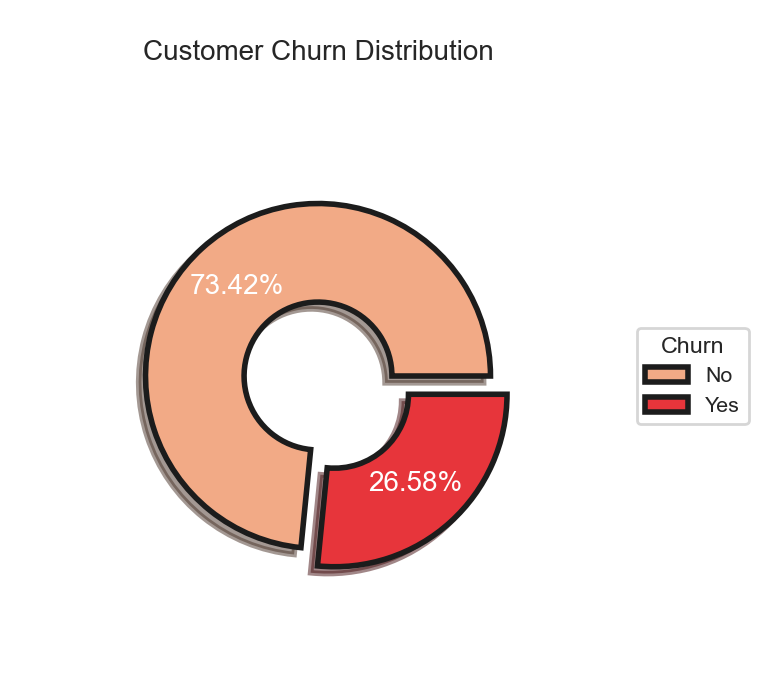

In [14]:
# Labels and values for customer churn
churn_labels = value_counts_churn.index.tolist()
churn_values = value_counts_churn.values.tolist()

fig, ax = plt.subplots(figsize=(8,8))

# Creating the pie chart
wedges, texts, autotexts = ax.pie(churn_values,
                                   labels=churn_labels,
                                   explode=(0, 0.1),
                                   textprops=dict(size=20, color="white"),
                                   autopct="%.2f%%",
                                   pctdistance=0.7,
                                   radius=0.7,
                                   colors=palette[2:],
                                   shadow=True,
                                   wedgeprops=dict(width=0.4, edgecolor="#1c1c1c", linewidth=4),
                                   startangle=0)

# Creating a legend and displaying the plot
ax.legend(wedges, churn_labels, title="Churn", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax.set_title("\nCustomer Churn Distribution", fontsize=20)
plt.show()

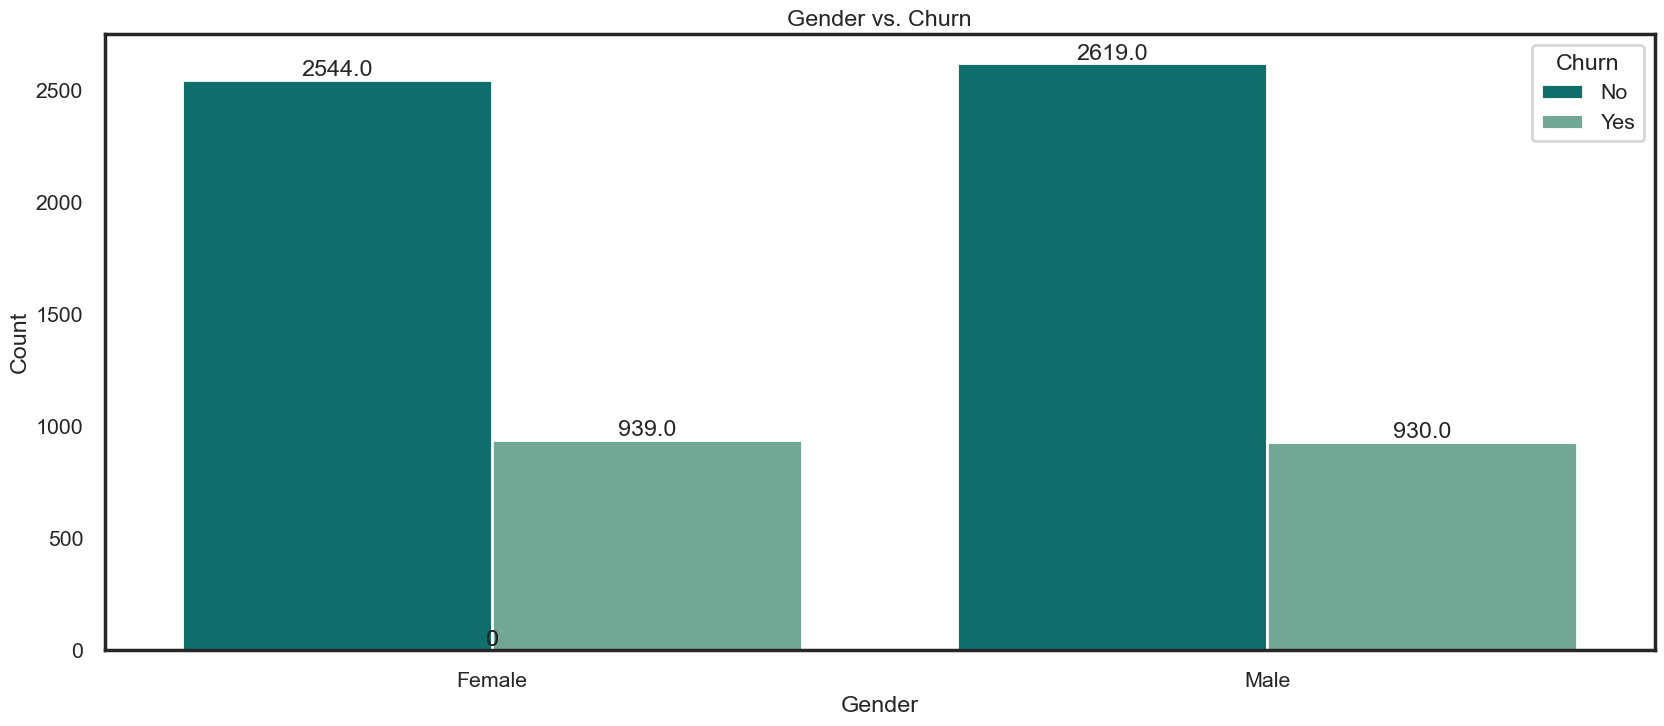

In [15]:
# Creating the count plot
plt.figure(figsize=(20, 8)) 
ax = sns.countplot(x='gender', hue='Churn', data=data, palette=palette[0:])

# Adding labels and title
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender vs. Churn")

# Calculating the count for each category
total = len(data)
for p in ax.patches:
    count = p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.text(x, y, f'{count}', ha='center', va='bottom')

# Displaying the count plot
plt.legend(title="Churn", loc='upper right', labels=['No', 'Yes'])
plt.show()

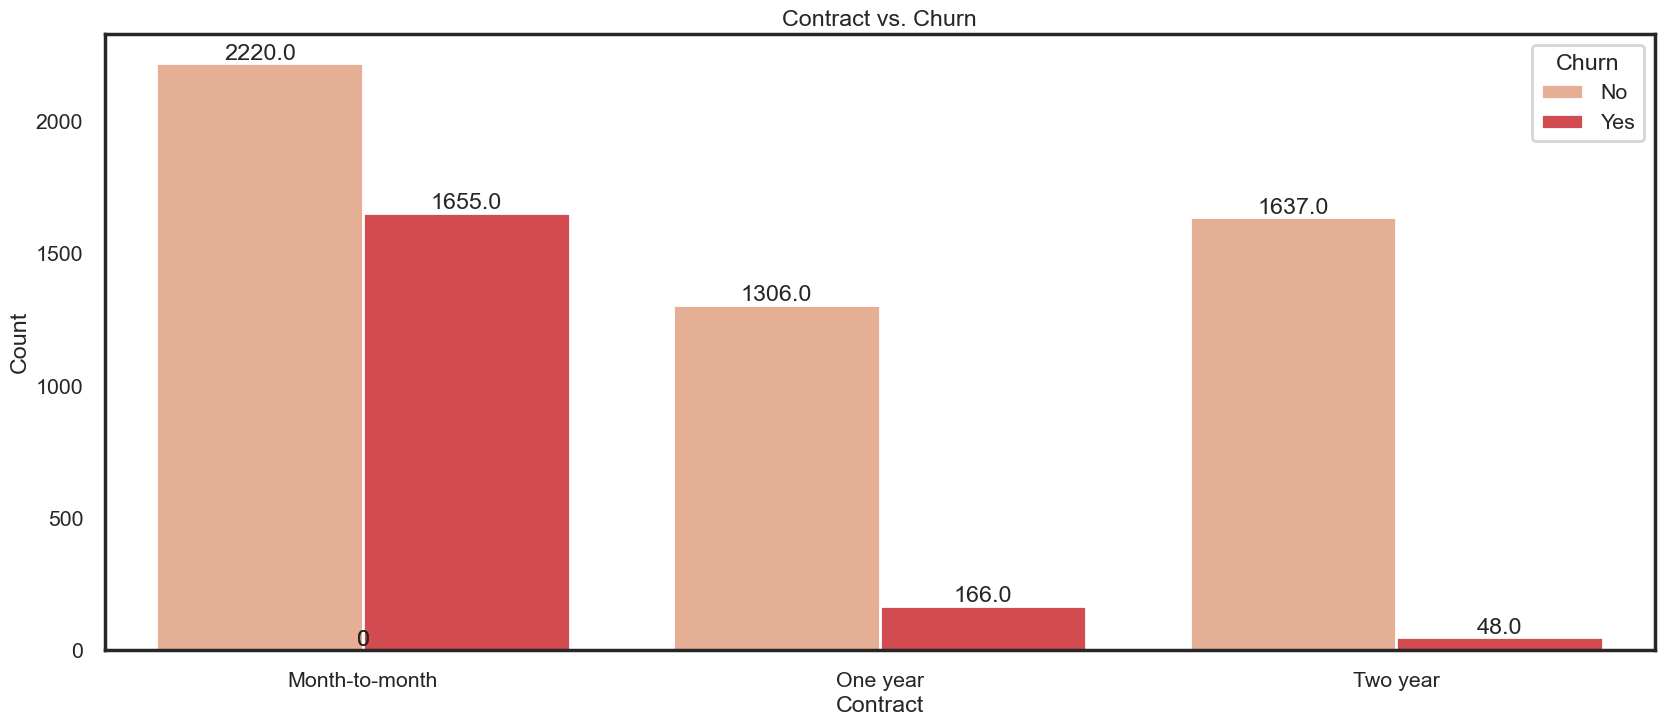

In [16]:
# Creating the count plot
plt.figure(figsize=(20, 8))  
ax = sns.countplot(x='Contract', hue='Churn', data=data, palette=palette[2:])

# Adding labels and title
plt.xlabel("Contract")
plt.ylabel("Count")
plt.title("Contract vs. Churn")

# Calculating the count for each category
total = len(data)
for p in ax.patches:
    count = p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.text(x, y, f'{count}', ha='center', va='bottom')

# Displaying the count plot
plt.legend(title="Churn", loc='upper right', labels=['No', 'Yes'])
plt.show()

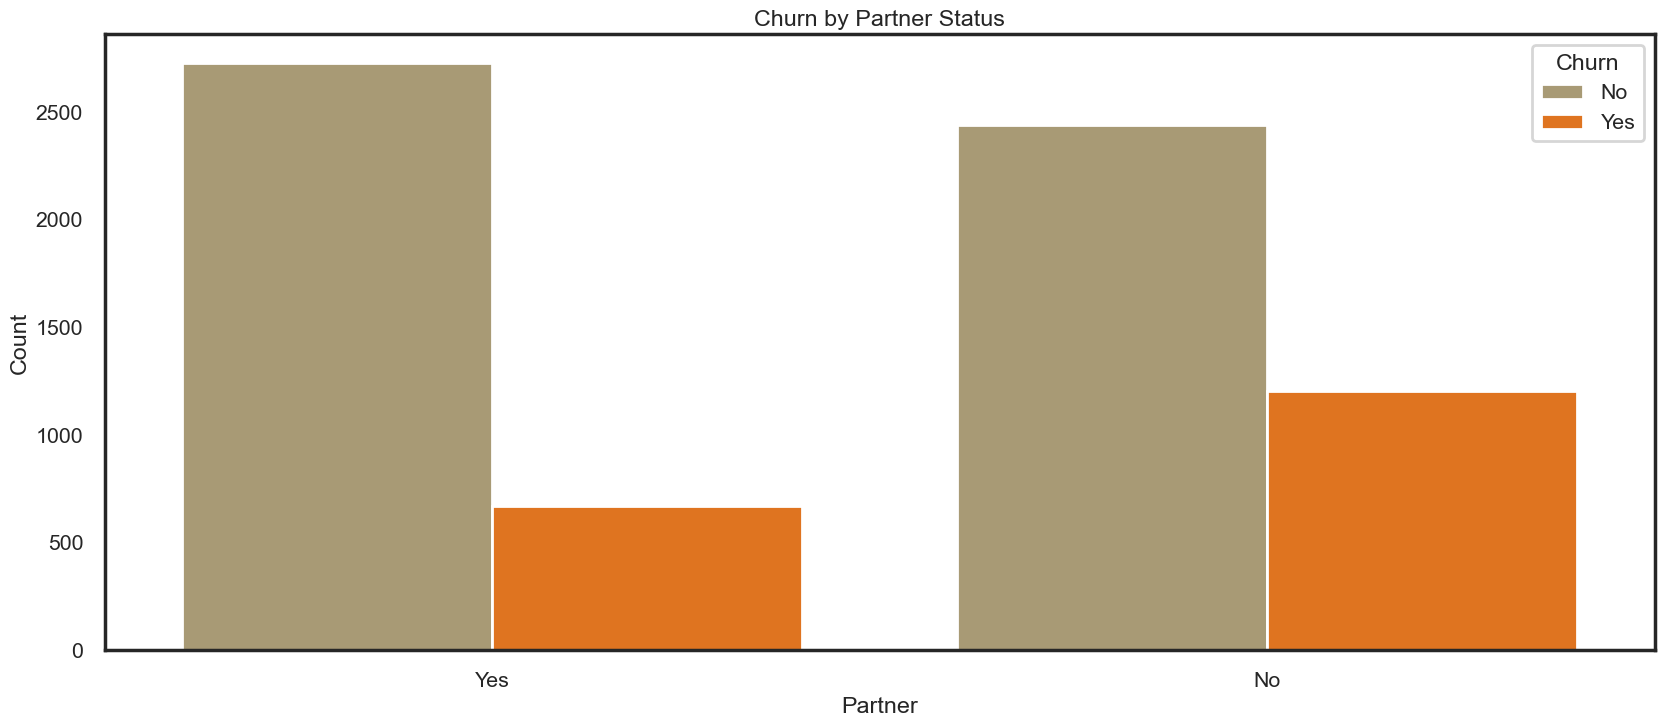

In [17]:
# Creating the stacked bar plot
plt.figure(figsize=(20, 8))  
sns.countplot(data=data, x='Partner', hue='Churn', palette=palette[5:])

# Adding labels and title
plt.xlabel("Partner")
plt.ylabel("Count")
plt.title("Churn by Partner Status")

# Displaying the plot
plt.legend(title="Churn", loc='upper right', labels=['No', 'Yes'])
plt.show()

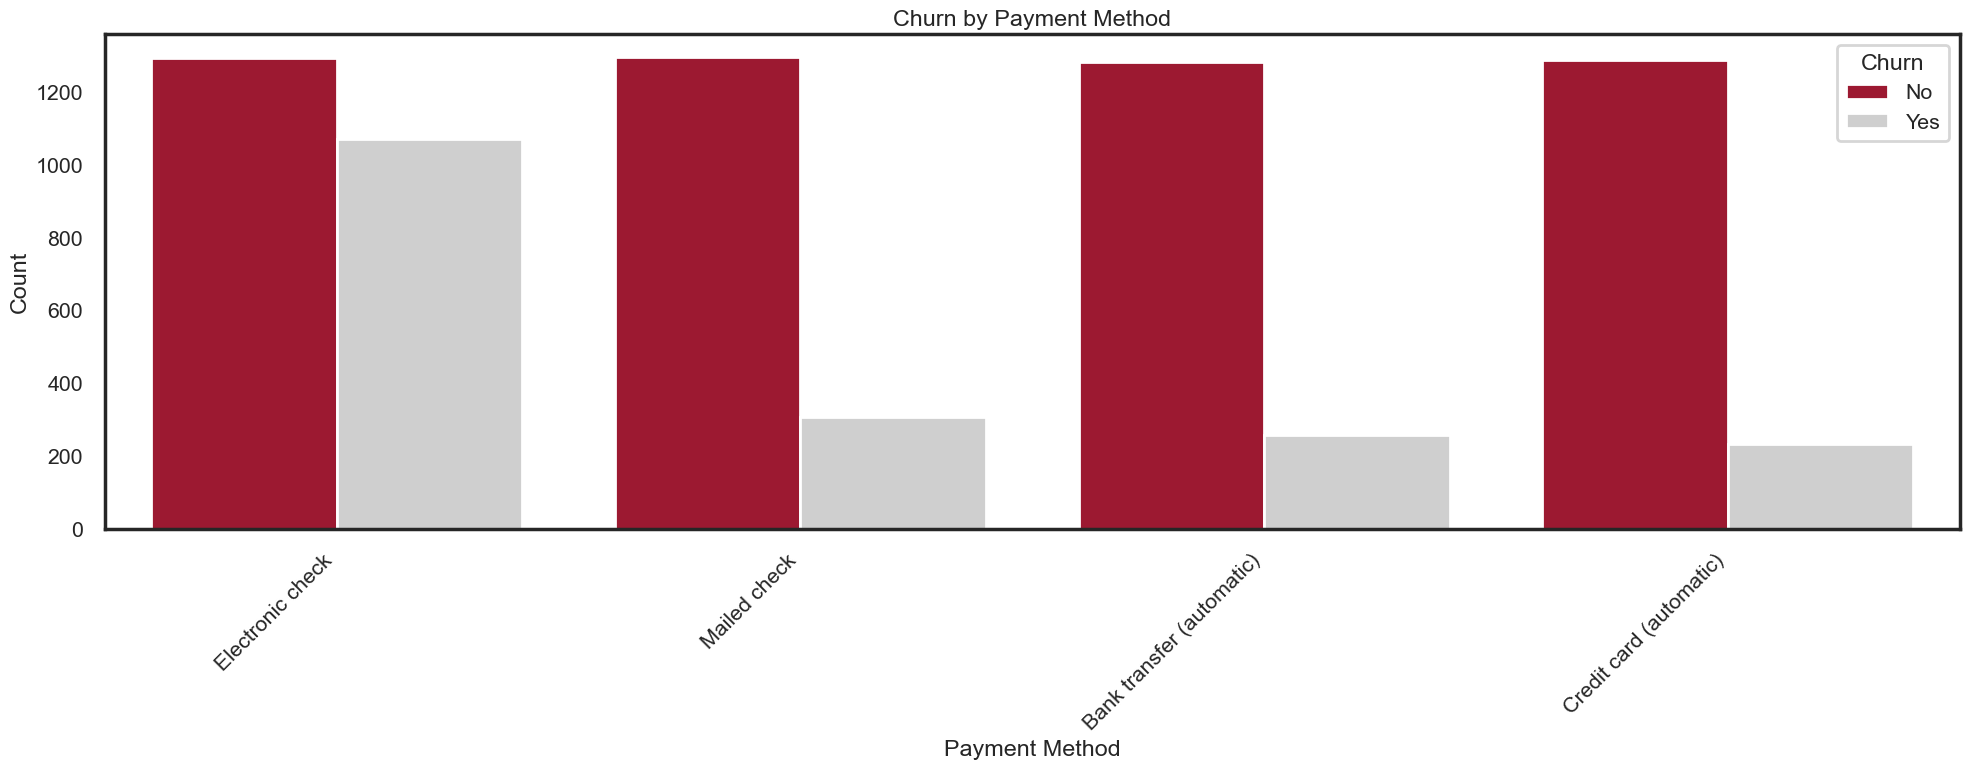

In [18]:
# Creating the stacked bar plot
plt.figure(figsize=(20, 8))
sns.countplot(data=data, x='PaymentMethod', hue='Churn', palette=palette[8:])

# Adding labels and title
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.title("Churn by Payment Method")

# Displaying the plot
plt.legend(title="Churn", loc='upper right', labels=['No', 'Yes'])
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()  # To prevent overlapping labels
plt.show()

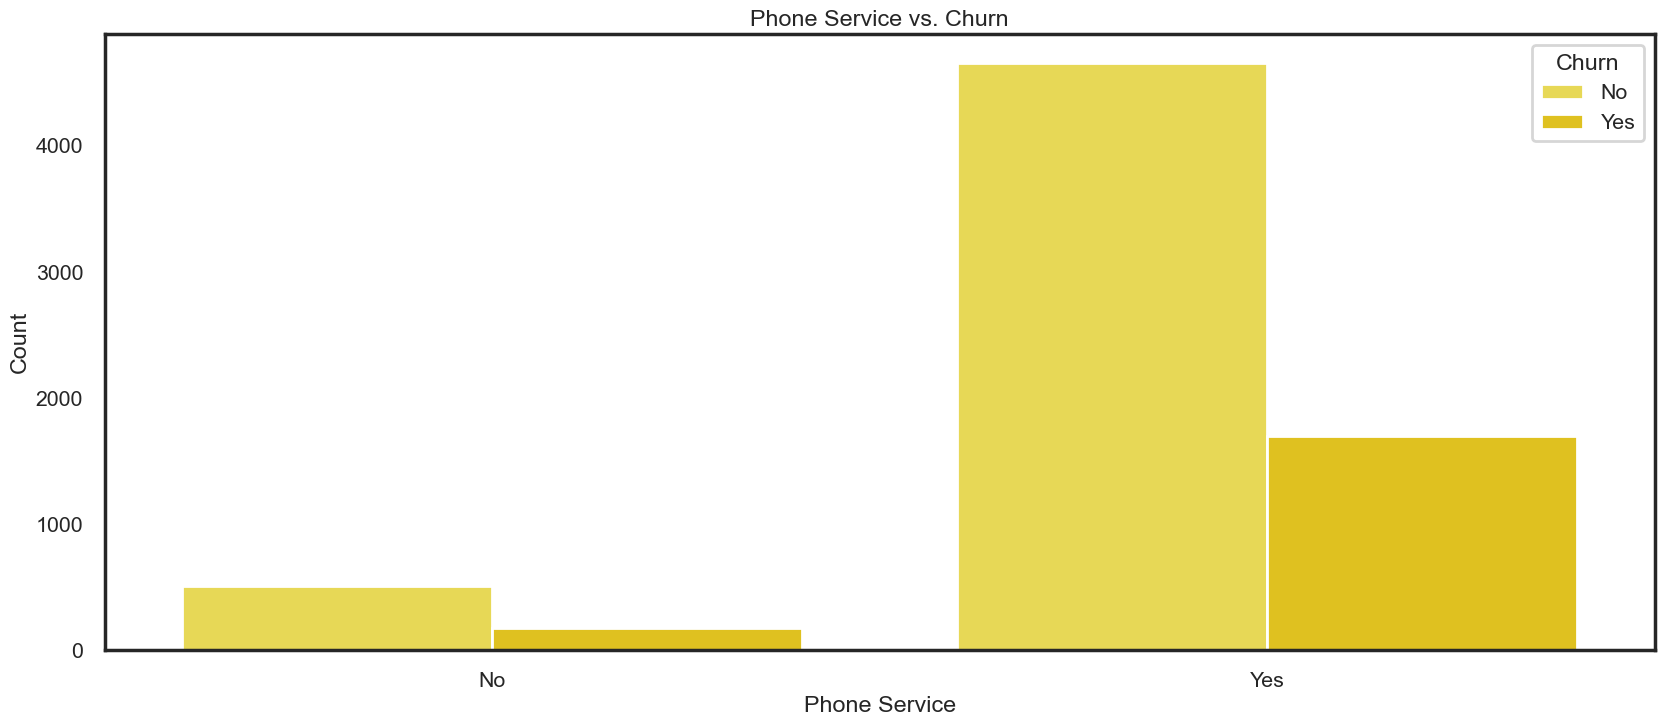

In [19]:
# Creating the count plot
plt.figure(figsize=(20,8))  
sns.countplot(x='PhoneService', hue='Churn', data=data, palette=palette[10:])

# Adding labels and title
plt.xlabel("Phone Service")
plt.ylabel("Count")
plt.title("Phone Service vs. Churn")

# Displaying the plot
plt.legend(title="Churn", loc='upper right', labels=['No', 'Yes'])
plt.show()

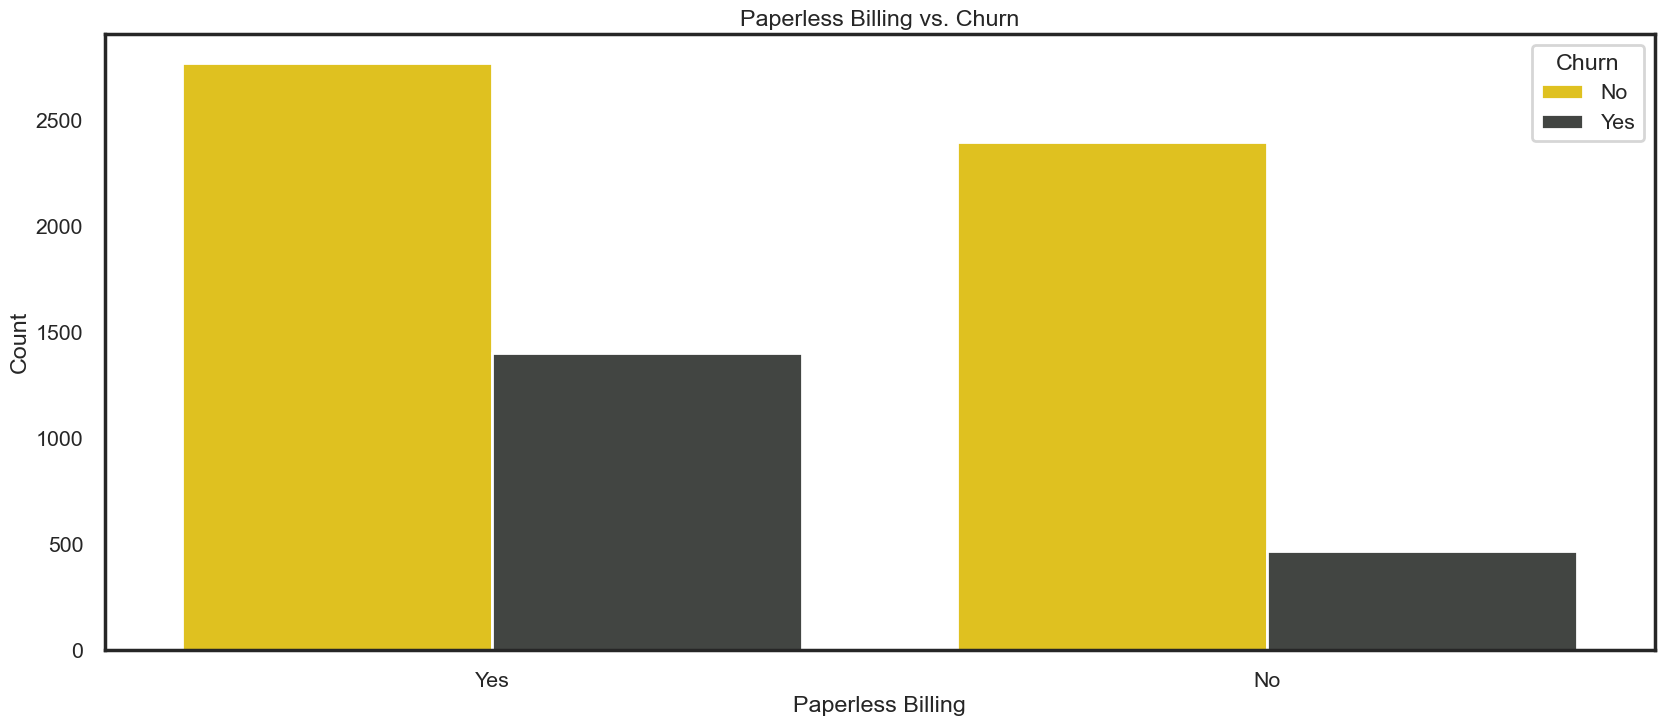

In [20]:
# Creating the count plot
plt.figure(figsize=(20, 8))  
sns.countplot(x='PaperlessBilling', hue='Churn', data=data, palette=palette[11:])

# Adding labels and title
plt.xlabel("Paperless Billing")
plt.ylabel("Count")
plt.title("Paperless Billing vs. Churn")

# Displaying the plot
plt.legend(title="Churn", loc='upper right', labels=['No', 'Yes'])
plt.show()

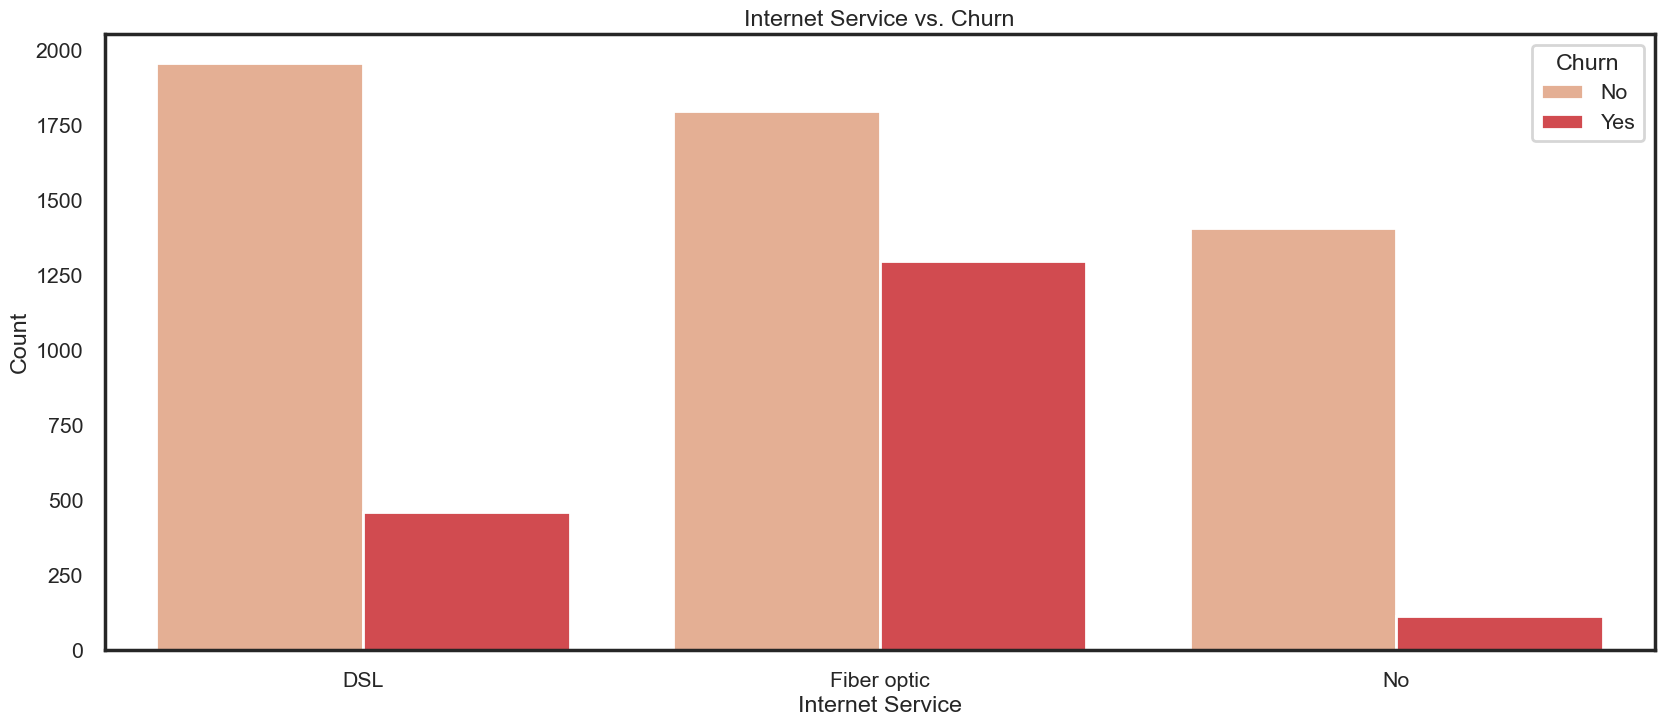

In [21]:
# Creating the count plot
plt.figure(figsize=(20, 8))  
sns.countplot(x='InternetService', hue='Churn', data=data, palette=palette[2:])

# Adding labels and title
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.title("Internet Service vs. Churn")

# Displaying the plot
plt.legend(title="Churn", loc='upper right', labels=['No', 'Yes'])
plt.show()

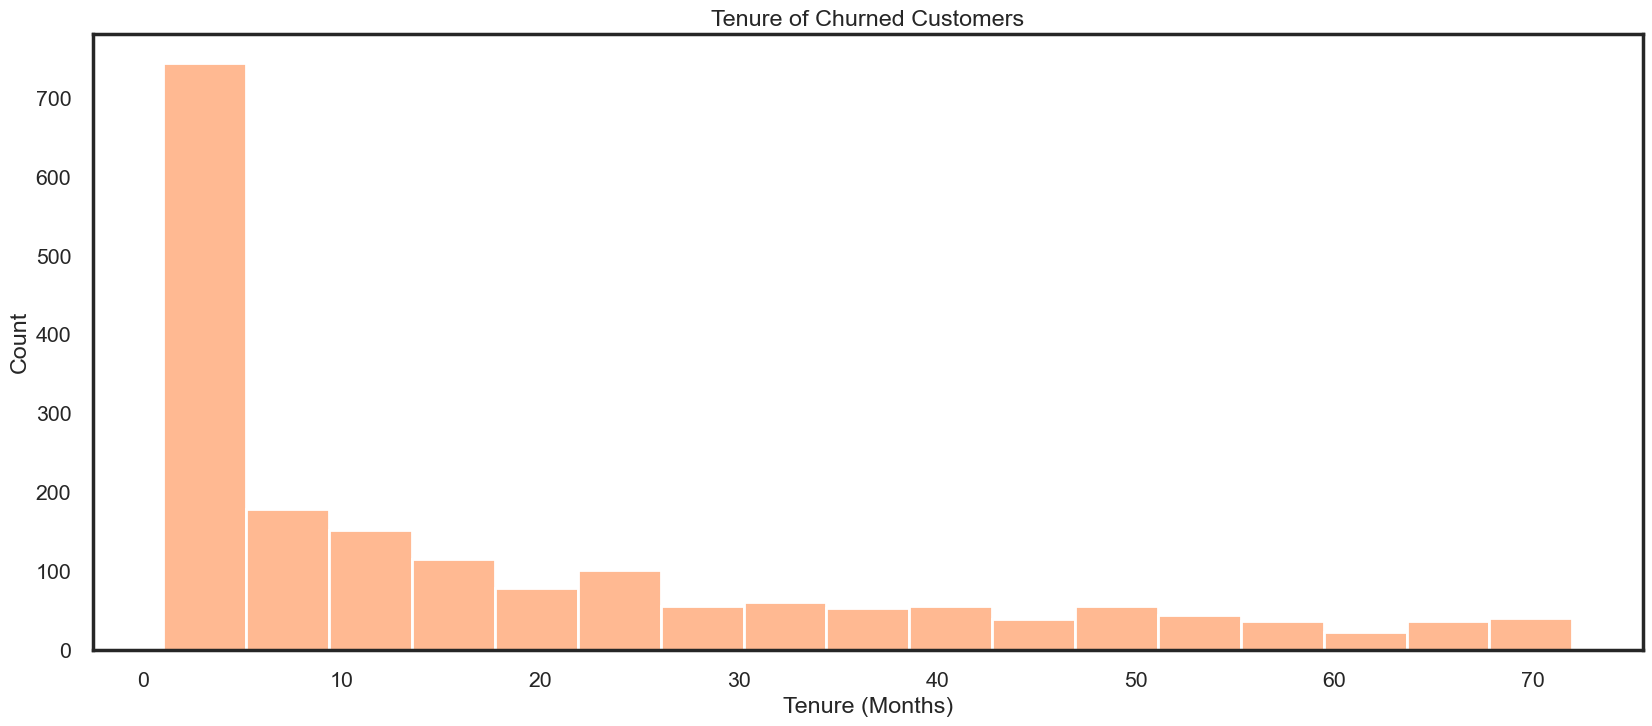

In [22]:
# Filtering the data for churned customers
churned_data = data[data['Churn'] == 'Yes']

# Creating the histogram
plt.figure(figsize=(20, 8))
sns.histplot(data=churned_data, x='tenure', bins='auto', color=palette[4])

# Adding labels and title
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.title("Tenure of Churned Customers")

# Displaying the plot
plt.show()

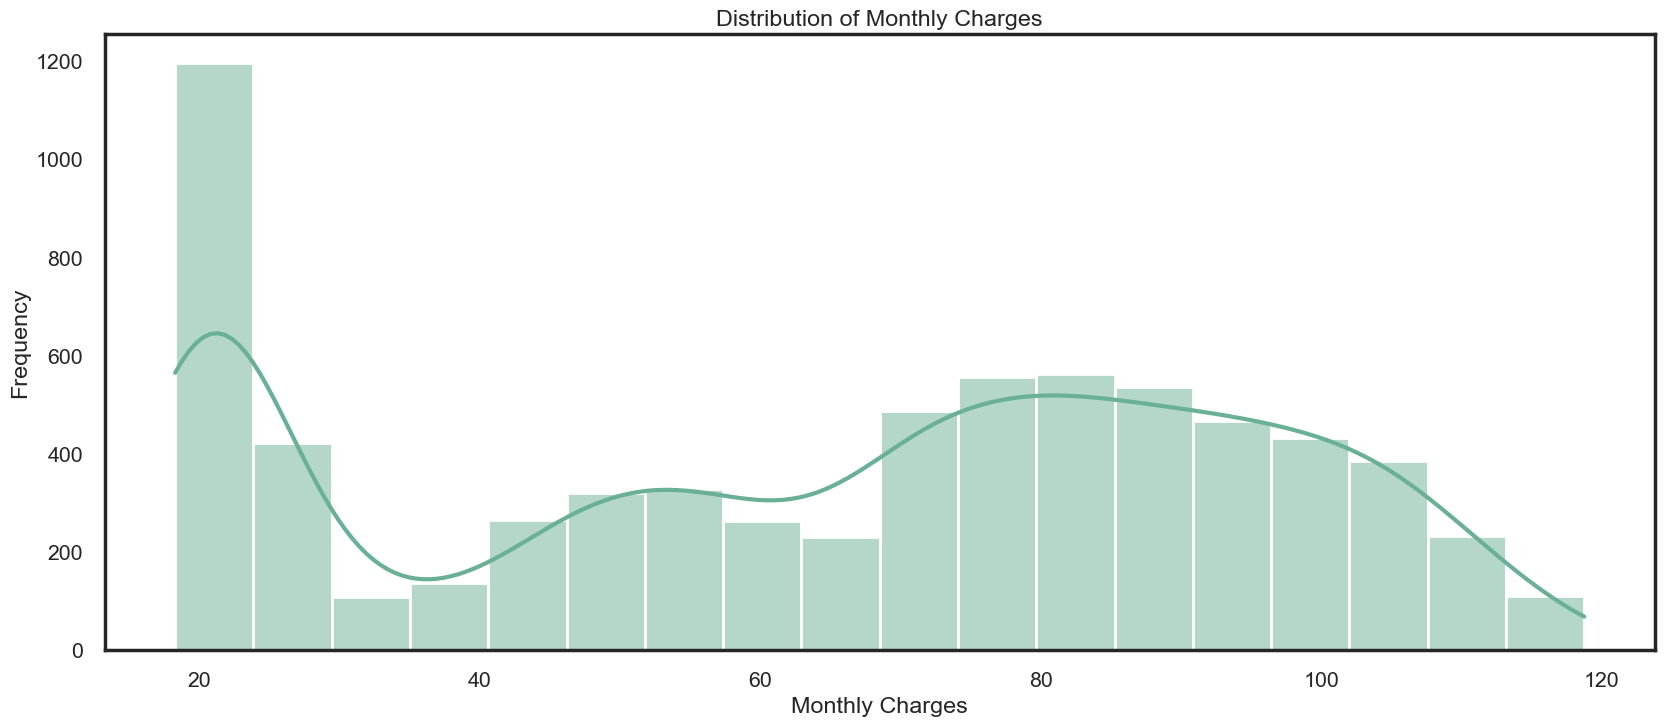

In [23]:
# Creating the histogram
plt.figure(figsize=(20, 8))
sns.histplot(data['MonthlyCharges'], bins='auto', kde=True, color=palette[1])

# Adding labels and title
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Monthly Charges")

# Displaying the plot
plt.show()

In [24]:
# Converting TotalCharges column into float values from object 
data['TotalCharges']=pd.to_numeric(data['TotalCharges'], errors='coerce')

In [25]:
# Identifying columns with exactly two unique values ('No' and 'Yes')
two_value_cols = [col for col in data.columns if data[col].nunique() == 2]

# Creating a dictionary to map 'No' to 0 and 'Yes' to 1
replace_dict = {'No': 0, 'Yes': 1}

# Applying the dictionary to convert No to 0 and Yes to 
for col in two_value_cols:
    data[col] = data[col].replace(replace_dict)

In [26]:
# Creatating a second dictionary to map the values to their respective replacements
replace_dict2 = {'No internet service': 0, 'No': 1, 'Yes': 2}

# Replacing the values in the column using the dictionary
data['OnlineSecurity'] = data['OnlineSecurity'].replace(replace_dict2)
data['OnlineBackup'] = data['OnlineBackup'].replace(replace_dict2)
data['DeviceProtection'] = data['DeviceProtection'].replace(replace_dict2)
data['TechSupport'] = data['TechSupport'].replace(replace_dict2)
data['StreamingTV'] = data['StreamingTV'].replace(replace_dict2)
data['StreamingMovies'] = data['StreamingMovies'].replace(replace_dict2)

In [27]:
# Replacing the values in MultipleLines, InternetServices and Contract Column
data['MultipleLines']=data['MultipleLines'].replace({'No phone service':0, 'No':1, 'Yes':2})
data['InternetService']=data['InternetService'].replace({'No':0, 'DSL':1, 'Fiber optic':2})
data['Contract']=data['Contract'].replace({'Month-to-month':0, 'One year':1, 'Two year':2})


In [28]:
# Performing one-hot encoding on 'PaymentMethod' and 'gender' columns
data = pd.get_dummies(data, columns=['gender','PaymentMethod'], drop_first=False)

In [29]:
print('Quick View at the dataset after pre-processing')

data.head(10).style.set_properties(**{'background-color':'#f4c095','color':'black','border':'2.5px solid black'})

Quick View at the dataset after pre-processing


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,1,1,2,1,1,1,1,0,1,29.850000,29.850000,0,True,False,False,False,True,False
1,0,0,0,34,1,1,1,2,1,2,1,1,1,1,0,56.950000,1889.500000,0,False,True,False,False,False,True
2,0,0,0,2,1,1,1,2,2,1,1,1,1,0,1,53.850000,108.150000,1,False,True,False,False,False,True
3,0,0,0,45,0,0,1,2,1,2,2,1,1,1,0,42.300000,1840.750000,0,False,True,True,False,False,False
4,0,0,0,2,1,1,2,1,1,1,1,1,1,0,1,70.700000,151.650000,1,True,False,False,False,True,False
5,0,0,0,8,1,2,2,1,1,2,1,2,2,0,1,99.650000,820.500000,1,True,False,False,False,True,False
6,0,0,1,22,1,2,2,1,2,1,1,2,1,0,1,89.100000,1949.400000,0,False,True,False,True,False,False
7,0,0,0,10,0,0,1,2,1,1,1,1,1,0,0,29.750000,301.900000,0,True,False,False,False,False,True
8,0,1,0,28,1,2,2,1,1,2,2,2,2,0,1,104.800000,3046.050000,1,True,False,False,False,True,False
9,0,0,1,62,1,1,1,2,2,1,1,1,1,1,0,56.150000,3487.950000,0,False,True,True,False,False,False


In [30]:
# Splitting the dataset into features (X) and the target variable (y)

X = data.drop(columns=['Churn']) 
y = data['Churn']

In [31]:
# Scalling the features using StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
# Splitting the data set into training and testing set

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [33]:
# Using Smote to balance the dataset by over sampling 

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [34]:
# Initializing classifier models
random_forest = RandomForestClassifier(random_state=42)
decision_tree = DecisionTreeClassifier(random_state=42)
svm_classifier = SVC(random_state=42)
naive_bayes = GaussianNB()
xgboost=XGBClassifier()


# Training the models on the training dataset
random_forest.fit(X_train_smote, y_train_smote)
decision_tree.fit(X_train_smote, y_train_smote)
svm_classifier.fit(X_train_smote, y_train_smote)
naive_bayes.fit(X_train_smote, y_train_smote)
xgboost.fit(X_train_smote, y_train_smote)


# predicting on the test dataset
y_pred_rf = random_forest.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_pred_svm = svm_classifier.predict(X_test)
y_pred_nb = naive_bayes.predict(X_test)
y_pred_xgb = xgboost.predict(X_test)


# Evaluating the models
print("Random Forest Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print()

print("Decision Tree Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))
print()

print("Support Vector Machine (SVM) Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print()

print("Naive Bayes Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1-score:", f1_score(y_test, y_pred_nb))
print()

print("XGBoost Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))

Random Forest Classifier:
Accuracy: 0.7732764747690121
Precision: 0.5729442970822282
Recall: 0.5775401069518716
F1-score: 0.5752330226364847

Decision Tree Classifier:
Accuracy: 0.7107320540156361
Precision: 0.4638949671772429
Recall: 0.5668449197860963
F1-score: 0.5102286401925391

Support Vector Machine (SVM) Classifier:
Accuracy: 0.746268656716418
Precision: 0.5158878504672897
Recall: 0.7379679144385026
F1-score: 0.6072607260726073

Naive Bayes Classifier:
Accuracy: 0.7050461975835111
Precision: 0.46831530139103555
Recall: 0.8101604278074866
F1-score: 0.5935357492654261

XGBoost Classifier:
Accuracy: 0.7654584221748401
Precision: 0.5558375634517766
Recall: 0.5855614973262032
F1-score: 0.5703125


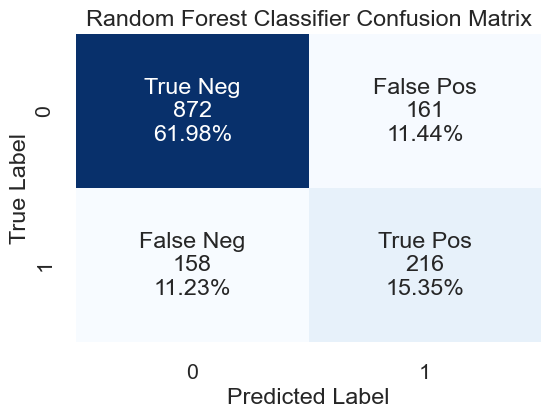

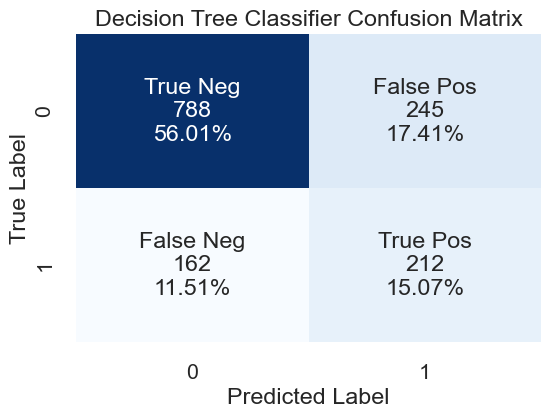

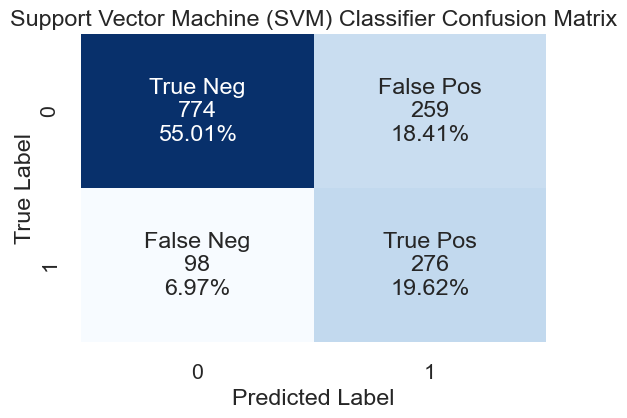

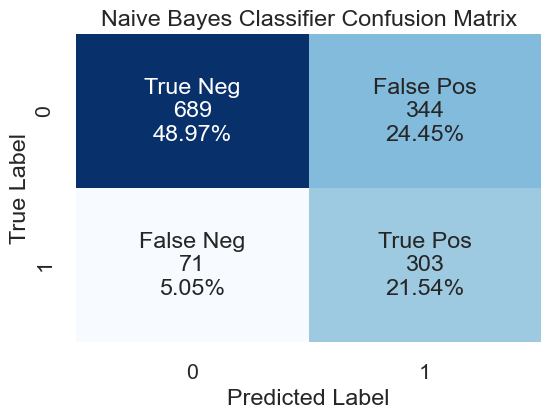

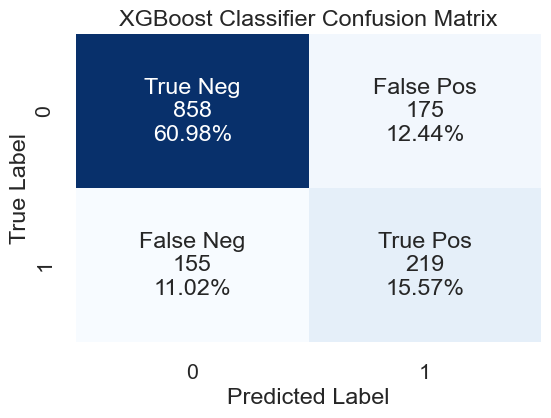

In [35]:
# Defining a function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten() / np.sum(cm)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

# Plotting confusion matrix for Random Forest Classifier
plot_confusion_matrix(y_test, y_pred_rf, title='Random Forest Classifier Confusion Matrix')

# Plotting confusion matrix for Decision Tree Classifier
plot_confusion_matrix(y_test, y_pred_dt, title='Decision Tree Classifier Confusion Matrix')

# Plotting confusion matrix for Support Vector Machine (SVM) Classifier
plot_confusion_matrix(y_test, y_pred_svm, title='Support Vector Machine (SVM) Classifier Confusion Matrix')

# Plotting confusion matrix for Naive Bayes Classifier
plot_confusion_matrix(y_test, y_pred_nb, title='Naive Bayes Classifier Confusion Matrix')

# Plotting confusion matrix for Light GBM Classifier
plot_confusion_matrix(y_test, y_pred_xgb, title='XGBoost Classifier Confusion Matrix')

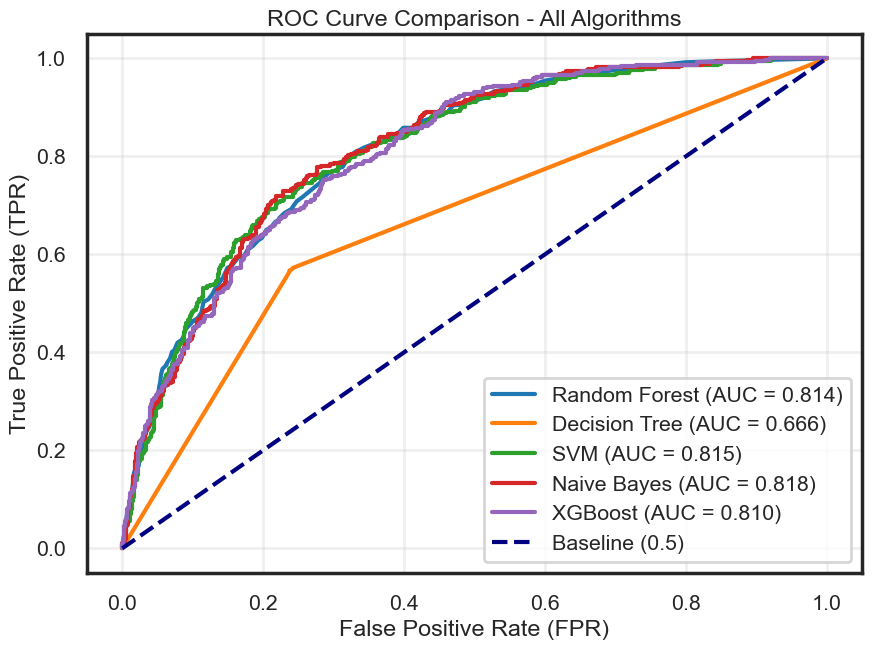

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Map your specific trained variables to the dictionary
models = {
    'Random Forest': random_forest,
    'Decision Tree': decision_tree,
    'SVM': svm_classifier,
    'Naive Bayes': naive_bayes,
    'XGBoost': xgboost
}

plt.figure(figsize=(10, 7))

for name, model in models.items():
    # 2. Get probability scores
    if name == 'SVM':
        # SVC usually uses decision_function unless probability=True is set
        probs = model.decision_function(X_test)
    else:
        # Others use predict_proba (column 1 for positive class)
        probs = model.predict_proba(X_test)[:, 1]
    
    # 3. Calculate AUC and Curve points
    auc = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# 4. Add the baseline and labels
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Baseline (0.5)')
plt.title('ROC Curve Comparison - All Algorithms')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()